<a href="https://www.kaggle.com/code/lalit7881/perfume-e-commerce-eda?scriptVersionId=313487902" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/aminasalamt/perfume-e-commerce-dataset/ebay_mens_perfume.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/aminasalamt/perfume-e-commerce-dataset/ebay_mens_perfume.csv")

In [3]:
df.head()

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States"
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada"
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States"
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,44.99,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States"
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States"


In [4]:
df.tail()

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
995,GUESS,Guess 1981 by Guess cologne for men EDT 3.3 / ...,Eau de Toilette,20.28,US $20.28/ea,45.0,"45 available / 1,613 sold",1613.0,"May 24, 2024 08:14:07 PDT","Dallas, Texas, United States"
996,Armaf,Club de Nuit Intense by Armaf cologne for men ...,Eau de Toilette,30.58,US $30.58,10.0,More than 10 available / 31 sold,31.0,"May 23, 2024 08:39:30 PDT",United States
997,Paco Rabanne,Invictus by Paco Rabanne for Men EDT Spray 3.4...,Eau de Toilette,39.99,US $39.99/ea,2.0,2 available / 305 sold,305.0,"May 23, 2024 15:27:18 PDT","Jamaica, New York, United States"
998,Lomani,"Lomani EDT Cologne 3.4 oz Men - Authentic, Bra...",Eau de Toilette,9.99,US $9.99/ea,2.0,2 available / 22 sold,22.0,"May 20, 2024 13:20:54 PDT","Lincoln Park, Michigan, United States"
999,Estee Lauder,Beyond Paradise by Estee Lauder for Men Cologn...,Cologne spray,17.49,US $17.49/ea,10.0,More than 10 available / 24 sold,24.0,"Feb 28, 2024 07:27:01 PST","Keyport, New Jersey, United States"


In [5]:
df.columns

Index(['brand', 'title', 'type', 'price', 'priceWithCurrency', 'available',
       'availableText', 'sold', 'lastUpdated', 'itemLocation'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              999 non-null    object 
 1   title              1000 non-null   object 
 2   type               997 non-null    object 
 3   price              1000 non-null   float64
 4   priceWithCurrency  1000 non-null   object 
 5   available          889 non-null    float64
 6   availableText      997 non-null    object 
 7   sold               994 non-null    float64
 8   lastUpdated        947 non-null    object 
 9   itemLocation       1000 non-null   object 
dtypes: float64(3), object(7)
memory usage: 78.3+ KB


In [7]:
df.describe()

,price,available,sold
count,1000.000000,889.000000,994.000000
mean,46.481200,20.046119,766.266600
std,35.527862,61.547985,3200.971733
min,3.000000,2.000000,1.000000
25%,22.990000,5.000000,14.000000
50%,35.710000,10.000000,49.500000
75%,59.000000,10.000000,320.500000
max,259.090000,842.000000,54052.000000


In [8]:
df.isnull().sum()

brand                  1
title                  0
type                   3
price                  0
priceWithCurrency      0
available            111
availableText          3
sold                   6
lastUpdated           53
itemLocation           0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

brand                 object
title                 object
type                  object
price                float64
priceWithCurrency     object
available            float64
availableText         object
sold                 float64
lastUpdated           object
itemLocation          object
dtype: object

In [11]:
df.shape

(1000, 10)

In [12]:
df.nunique()

brand                246
title                966
type                  63
price                601
priceWithCurrency    685
available             89
availableText        758
sold                 428
lastUpdated          933
itemLocation         276
dtype: int64

## EDA

            brand                                              title  \
0            Dior  Christian Dior Sauvage Men's EDP 3.4 oz Fragra...   
1         AS SHOW  A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...   
2       Unbranded                   HOGO BOSS cologne For Men 3.4 oz   
3  Giorgio Armani  Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...   
4         Lattafa  Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...   

              type   price priceWithCurrency  available  \
0    Eau de Parfum   84.99      US $84.99/ea       10.0   
1    Eau de Parfum  109.99        US $109.99        8.0   
2  Eau de Toilette  100.00        US $100.00       10.0   
3  Eau de Toilette   44.99      US $44.99/ea        2.0   
4       Fragrances   16.91         US $16.91        NaN   

                           availableText   sold                lastUpdated  \
0      More than 10 available / 116 sold  116.0  May 24, 2024 10:03:04 PDT   
1                  8 available / 48 sold   48.0  May 23,

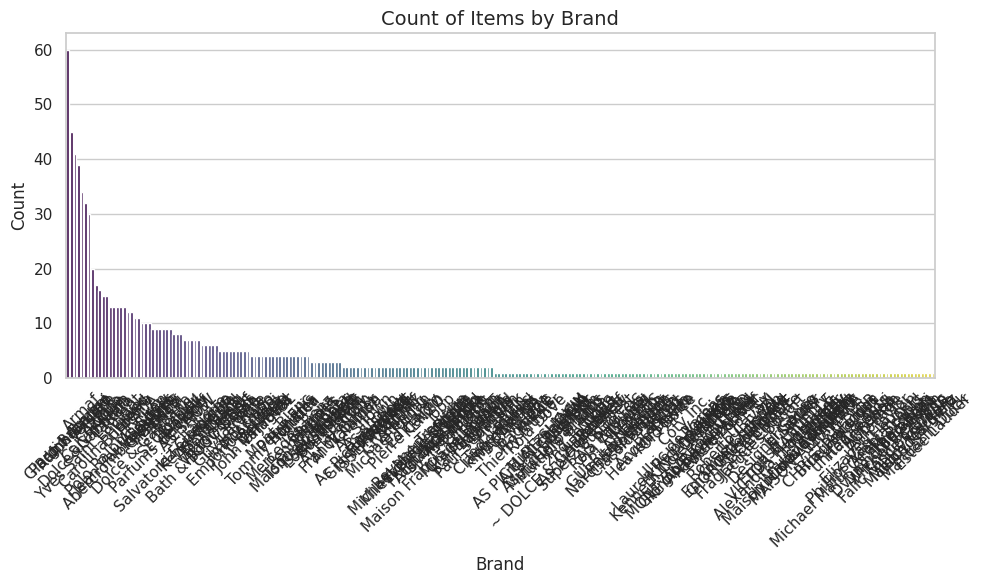

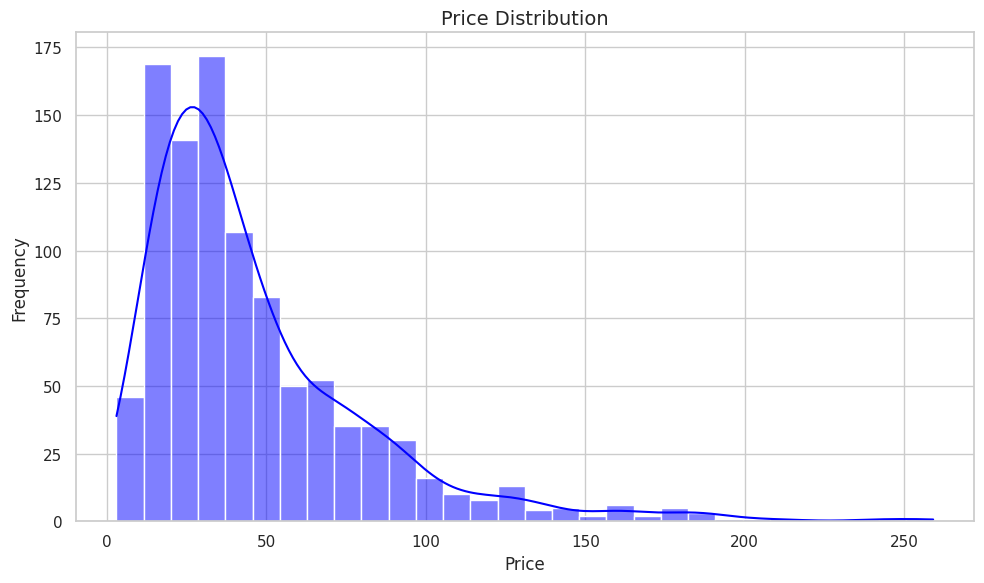

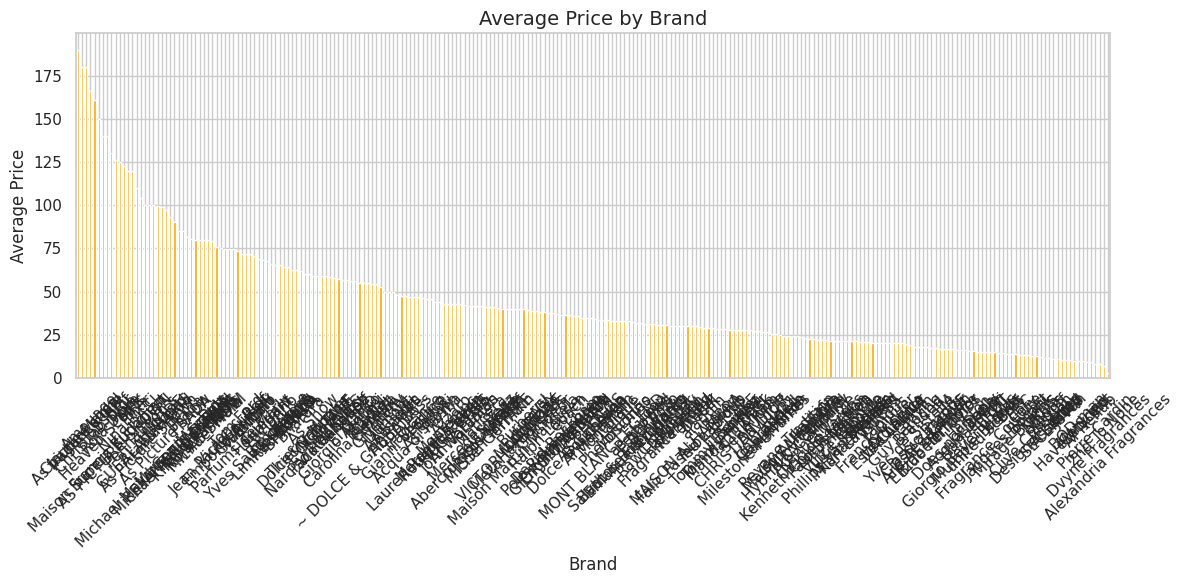

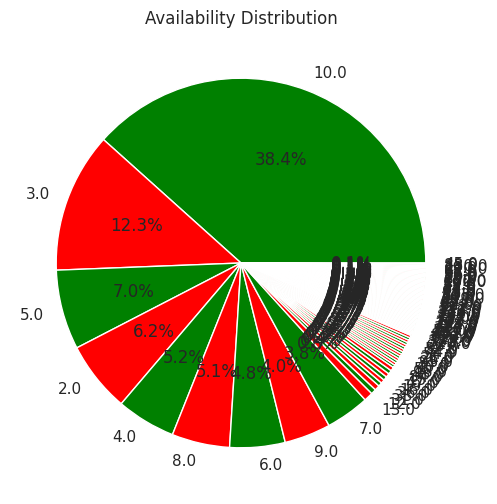

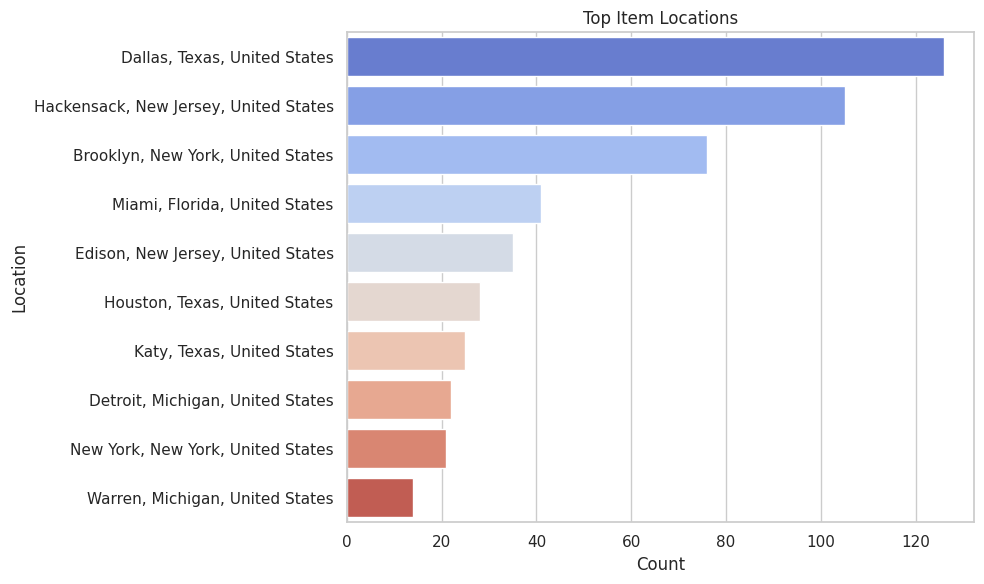

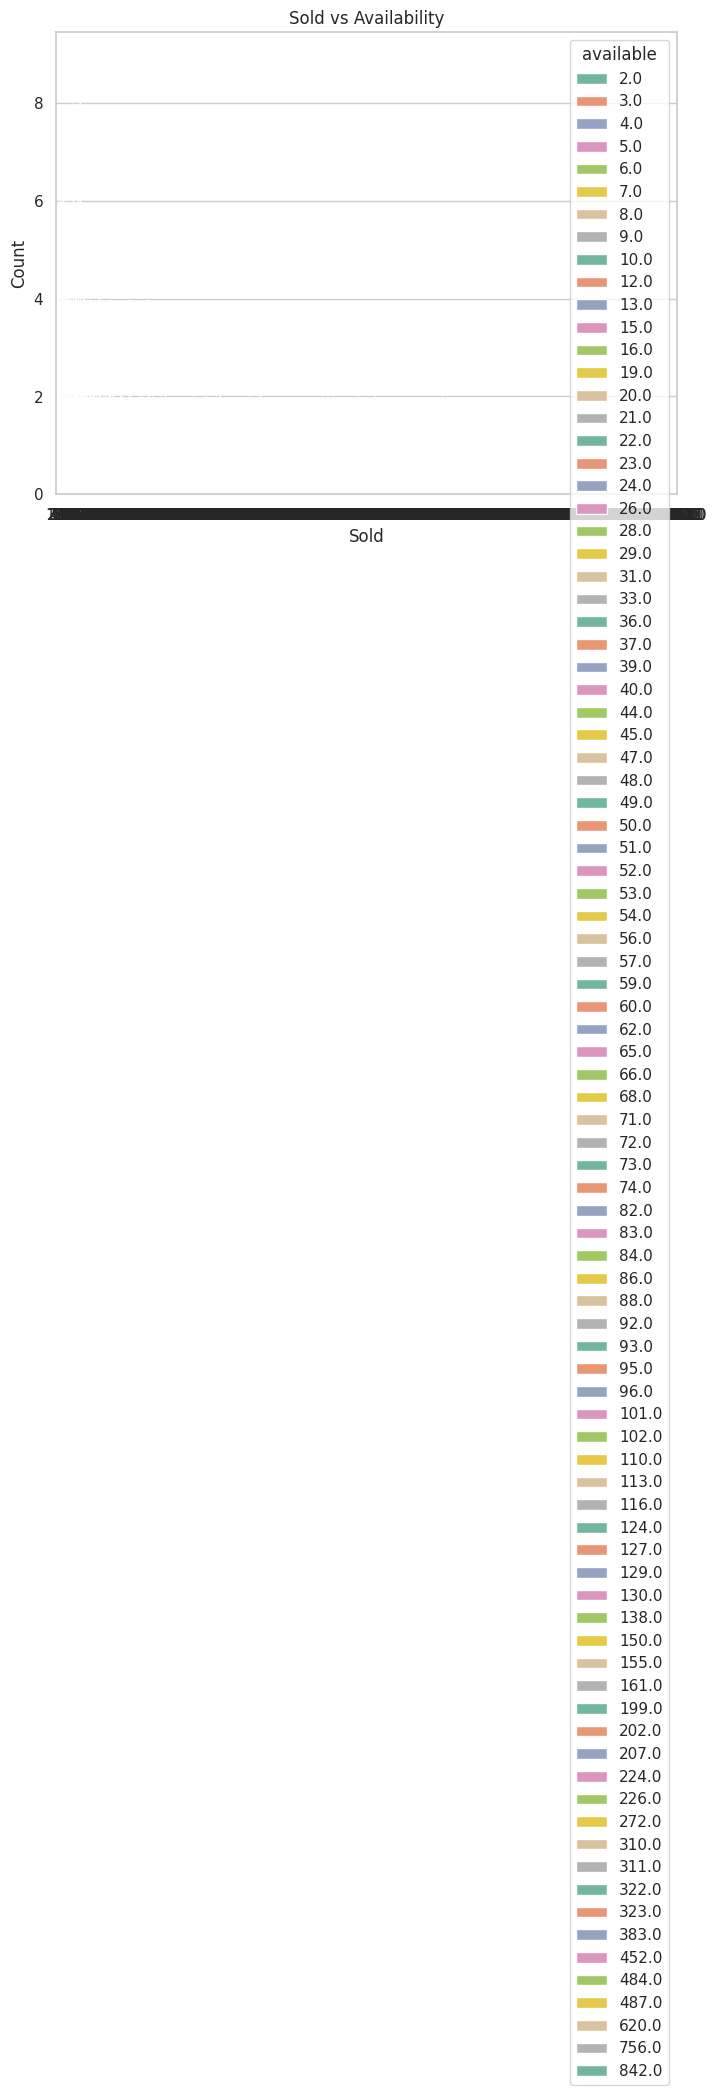

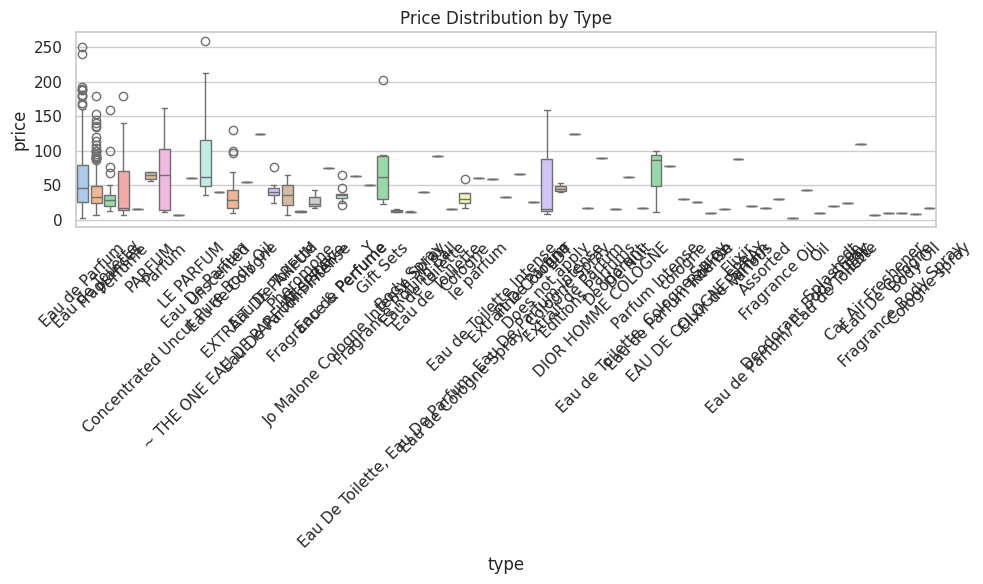

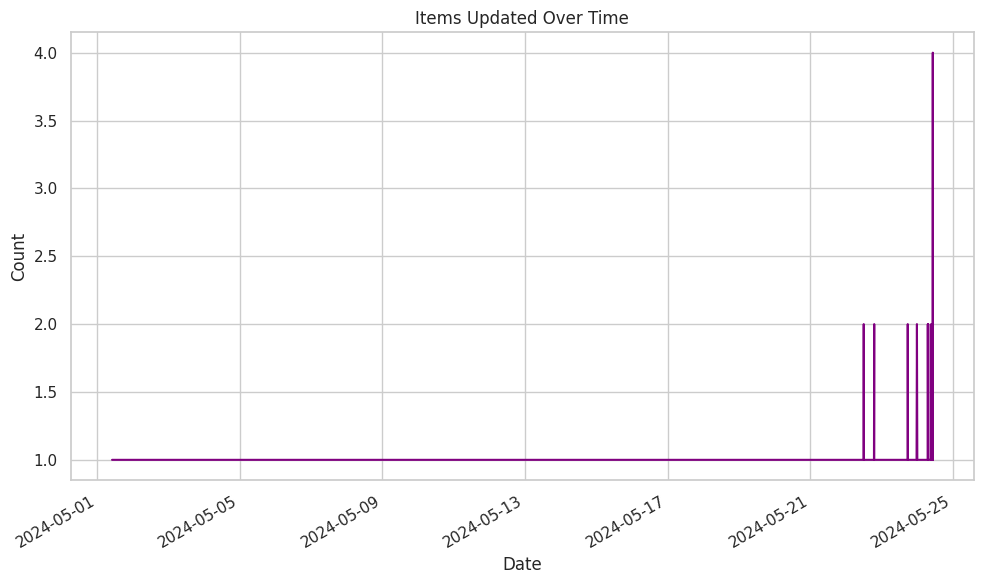

In [13]:
# Basic info
print(df.head())
print(df.info())

# Convert price to numeric (if needed)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Set style
sns.set(style="whitegrid")

# -------------------------------
# 1. Count of Items by Brand
# -------------------------------
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='brand', order=df['brand'].value_counts().index, palette='viridis')
plt.xticks(rotation=45)
plt.title("Count of Items by Brand", fontsize=14)
plt.xlabel("Brand")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# -------------------------------
# 2. Price Distribution
# -------------------------------
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=30, kde=True, color='blue')
plt.title("Price Distribution", fontsize=14)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# -------------------------------
# 3. Average Price by Brand
# -------------------------------
plt.figure(figsize=(12,6))
avg_price = df.groupby('brand')['price'].mean().sort_values(ascending=False)
avg_price.plot(kind='bar', color='orange')
plt.title("Average Price by Brand", fontsize=14)
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------------
# 4. Item Availability Count
# -------------------------------
plt.figure(figsize=(6,6))
df['available'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['green','red'])
plt.title("Availability Distribution")
plt.ylabel("")
plt.show()

# -------------------------------
# 5. Top Item Locations
# -------------------------------
plt.figure(figsize=(10,6))
top_locations = df['itemLocation'].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index, palette='coolwarm')
plt.title("Top Item Locations")
plt.xlabel("Count")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

# -------------------------------
# 6. Sold vs Available (Countplot)
# -------------------------------
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='sold', hue='available', palette='Set2')
plt.title("Sold vs Availability")
plt.xlabel("Sold")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# -------------------------------
# 7. Price by Type (Boxplot)
# -------------------------------
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='type', y='price', palette='pastel')
plt.xticks(rotation=45)
plt.title("Price Distribution by Type")
plt.tight_layout()
plt.show()

# -------------------------------
# 8. Last Updated Trend
# -------------------------------
df['lastUpdated'] = pd.to_datetime(df['lastUpdated'], errors='coerce')

plt.figure(figsize=(10,6))
df['lastUpdated'].value_counts().sort_index().plot(color='purple')
plt.title("Items Updated Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Feature engineering

Columns: ['brand', 'title', 'type', 'price', 'pricewithcurrency', 'available', 'availabletext', 'sold', 'lastupdated', 'itemlocation']

Logistic Regression
Accuracy: 0.985
ROC AUC: 0.844331641285956
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       197
           1       0.00      0.00      0.00         3

    accuracy                           0.98       200
   macro avg       0.49      0.50      0.50       200
weighted avg       0.97      0.98      0.98       200


Random Forest
Accuracy: 0.985
ROC AUC: 0.6505922165820642
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       197
           1       0.00      0.00      0.00         3

    accuracy                           0.98       200
   macro avg       0.49      0.50      0.50       200
weighted avg       0.97      0.98      0.98       200


Decision Tree
Accuracy: 0.95
ROC AUC: 0.48223350253807107
              precision    re

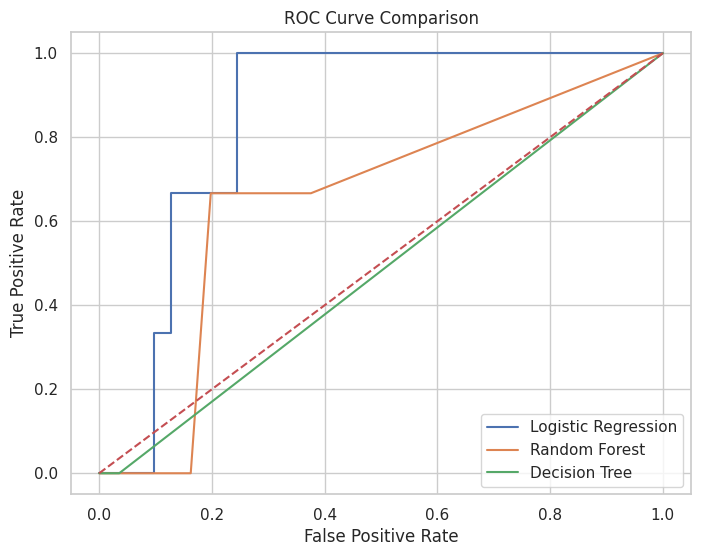


Best Model (based on ROC AUC): Logistic Regression


In [14]:
# ML imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# -------------------------------
# 2. CLEAN COLUMN NAMES (IMPORTANT)
# -------------------------------
df.columns = df.columns.str.strip().str.lower()

print("Columns:", df.columns.tolist())

# -------------------------------
# 3. HANDLE PRICE COLUMN SAFELY
# -------------------------------
if 'price' in df.columns:
    df['price'] = pd.to_numeric(df['price'], errors='coerce')

elif 'pricewithcurrency' in df.columns:
    df['price'] = df['pricewithcurrency'].astype(str).replace('[^0-9.]', '', regex=True)
    df['price'] = pd.to_numeric(df['price'], errors='coerce')

else:
    raise Exception("No price column found in dataset")

# -------------------------------
# 4. HANDLE TARGET COLUMN
# -------------------------------
# Convert 'sold' into binary target
if df['sold'].dtype == object:
    df['target'] = df['sold'].astype(str).str.lower().map({'true':1, 'false':0})
else:
    df['target'] = df['sold'].apply(lambda x: 1 if x==True else 0)

# Drop rows where target is missing
df = df.dropna(subset=['target'])

# -------------------------------
# 5. SELECT FEATURES
# -------------------------------
features = ['brand', 'type', 'price', 'available']

# Keep only available columns
features = [col for col in features if col in df.columns]

X = df[features]
y = df['target']

# -------------------------------
# 6. TRAIN TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 7. PREPROCESSING PIPELINE
# -------------------------------
categorical_cols = [col for col in ['brand', 'type', 'available'] if col in X.columns]
numeric_cols = [col for col in ['price'] if col in X.columns]

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# -------------------------------
# 8. MODELS
# -------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Decision Tree": DecisionTreeClassifier()
}

results = {}

# -------------------------------
# 9. TRAIN + EVALUATE
# -------------------------------
plt.figure(figsize=(8,6))

for name, model in models.items():
    
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:,1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    results[name] = roc
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("ROC AUC:", roc)
    print(classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# -------------------------------
# 10. BEST MODEL
# -------------------------------
best_model = max(results, key=results.get)
print("\nBest Model (based on ROC AUC):", best_model)

## Thank you...pls upvote!!!!!!!!!